In [67]:
import pandas as pd

# Amazon Cardinality

In [68]:
results_df =  pd.read_csv('C:\\Users\Ronza\Dev\DP-MSD\\amazon\\results\\results_from_server\Amazon_Greedy_Results.csv')

In [69]:
results_df

,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,nonpriv,10,0.1,0.1,0,0.206032,0.196940,0.287856,9957,2.5307
1,DPGreedy,10,0.1,0.1,0,0.206032,0.196940,0.287856,9957,2.5883
2,DPSampleOblGreedy,10,0.1,0.1,0,0.194992,0.188656,0.252013,2310,0.7750
3,DPSampleGreedy,10,0.1,0.1,0,0.205532,0.198117,0.272266,4489,1.2608
4,Random,10,0.1,0.1,0,0.034954,0.002508,0.326966,0,0.0009
...,...,...,...,...,...,...,...,...,...,...
1245,nonpriv,15,0.8,0.1,9,0.323853,0.123479,0.373947,14897,3.7951
1246,DPGreedy,15,0.8,0.1,9,0.320313,0.081744,0.379955,14897,3.6196
1247,DPSampleOblGreedy,15,0.8,0.1,9,0.315478,0.115917,0.365368,2311,0.7096
1248,DPSampleGreedy,15,0.8,0.1,9,0.315814,0.101950,0.369280,5303,1.4510


## Impact of k on score

In [70]:
results_df['alg'] = results_df['alg'].replace(
    {
        'nonpriv': 'Greedy',
        'DPGreedy': 'DP-Greedy',
        'DPSampleOblGreedy': 'DP-OSG',
        'DPSampleGreedy': 'DP-NOSG',
        'Random': 'Random'
    }
)

In [71]:
print(results_df.head())    

         alg   k  lambda_param  eps  rep     value  relevance  diversity  \
0     Greedy  10           0.1  0.1    0  0.206032   0.196940   0.287856   
1  DP-Greedy  10           0.1  0.1    0  0.206032   0.196940   0.287856   
2     DP-OSG  10           0.1  0.1    0  0.194992   0.188656   0.252013   
3    DP-NOSG  10           0.1  0.1    0  0.205532   0.198117   0.272266   
4     Random  10           0.1  0.1    0  0.034954   0.002508   0.326966   

   queries  time_sec  
0     9957    2.5307  
1     9957    2.5883  
2     2310    0.7750  
3     4489    1.2608  
4        0    0.0009  


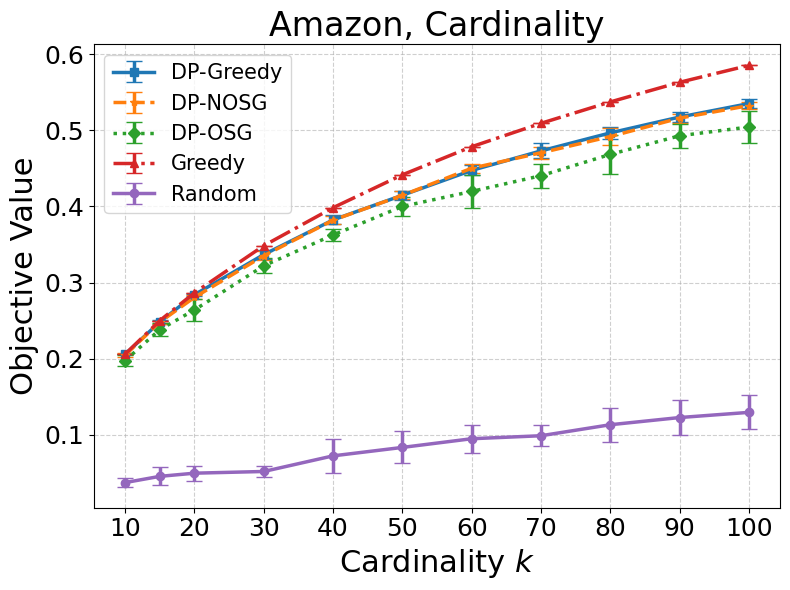

In [72]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Cardinality', fontsize=24)

plt.xticks(range(10, 110, 10), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_cardinality_k_on_val.pdf')
plt.show()

## Impact of eps on score

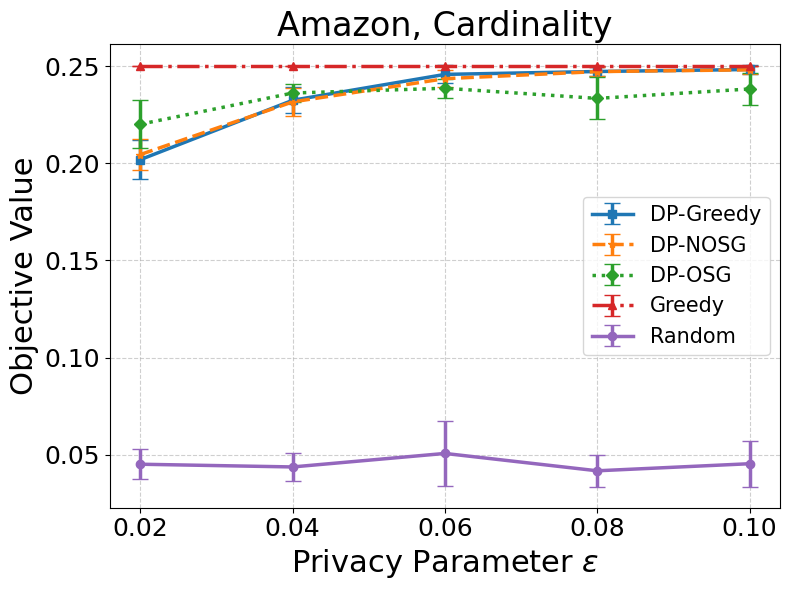

In [73]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 15 
eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(8, 6)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    plt.errorbar(
        alg_data['eps'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  
        markersize=6,   # Exact size from your reference
        capsize=6       
    )

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Amazon, Cardinality', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=15, frameon=True) # Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('amazon_cardinality_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

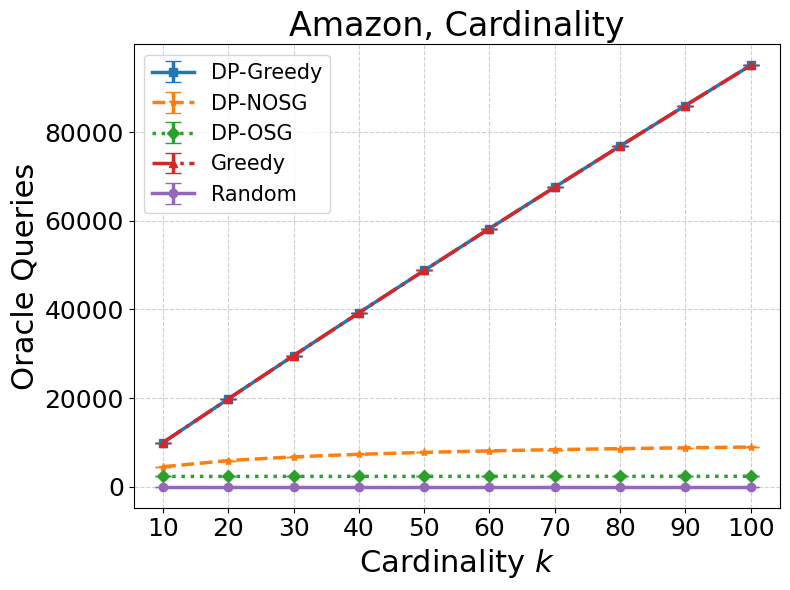

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1) & results_df['k'].isin(list(range(10, 110, 10)))]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Amazon, Cardinality', fontsize=24)

plt.xticks(range(10, 110, 10), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_k_on_queries.pdf')
plt.show()

## Impact of k on execution time

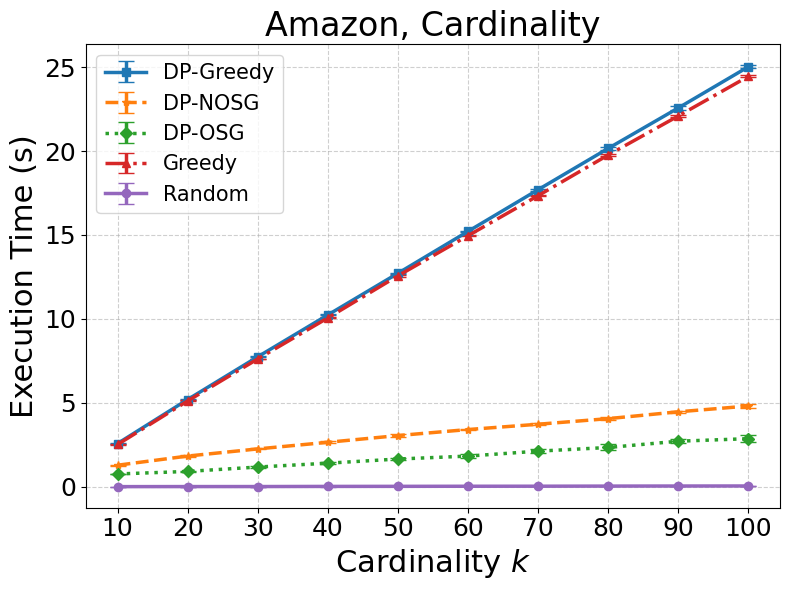

In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1) & results_df['k'].isin(list(range(10, 110, 10)))]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(8, 6)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-', '--', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    plt.errorbar(
        alg_data['k'], 
        alg_data['mean'], 
        yerr=alg_data['std'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2.5,  # Slightly thicker lines
        markersize=6,  # Larger markers for better visibility
        capsize=6       # Distinct caps for the error bars
    )

# Formatting for large text relative to the image size
plt.xlabel('Cardinality $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Amazon, Cardinality', fontsize=24)

plt.xticks(range(10, 110, 10), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=15, frameon=True) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('amazon_k_on_time.pdf')
plt.show()

# Matroid Constraints